Data Science 100 Project (Individual) — Rowan Flores 55736094 (Group 39)

In [36]:
library(tidyverse)

In [37]:
players <- read_csv("Project Planning Players.csv")

Rows: 196 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): experience, hashedEmail, name, gender
dbl (2): played_hours, Age
lgl (1): subscribe

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [38]:
stage_sessions <- read_csv("Project Planning Players.csv")

Rows: 196 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): experience, hashedEmail, name, gender
dbl (2): played_hours, Age
lgl (1): subscribe

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


1) Data Description

The data is split into to data frames:
- the first is called Project Planning Players (1)
- the second is called Project Planning Stage Sessions (2)

Number of observations: 
- (1) - 1372
- (2) - 7675

Variables:

(1)
- logical (lgl): subscribe
- character (chr): experience, hashedEmail, name, gender
- numberic (dbl): played_hours, Age

(2)
- character (chr): hashedEmail, start_time, end_time
- numeric (dbl): original_start_time, original_end_time


Description of Variables:

(1)
- subscibe - whether the user subscribed to email updates
- experience - the player's experience level with Minecraft
- hashedEmail - scrambled email
- name - player's name
- gender - player's gender
- Age - player's age
- played_hours - the total hours a player has played

(2)
- hashedEmail - same as above
- start_time - when a player began a session (date and clock time)
- end_time - when a player ended a session (date and clock time)
- original_start_time - start time using universal timestamp in milliseconds (help from ChatGPT)
- original_end_time - end time using universal timestamp in milliseconds (help from ChatGPT)

Errors and Issues: 

(1)
- not many visible errors, a few NA's, potential issues with reading 0s in data
- hidden issues: unscaled data

(2)
- missing start or end times, multiple variables in a single column (date and timestamp)
- hidden issues: unscaled, difficult data to work with (milliseconds)


2. Question

Broad Question: 
- Question 1: "What player characteristics and behaviours are most predictive of subscribing to a game-related newsletter, and how do these features differ between various player types?"

Narrow Question: 
- Can age, experience, and time spent on the Minecraft server predict a user's likelihood to subscribe to a game-related newsletter in the Project Planning Players data set?

I will be able to use the project planning players data to demonstrate if there is a correlation between the variables I have chosen. With this connection, I should be able to predict whether a player is likely to subscribe to the newsletter or not.

Some wrangling is necessary to ensure that the data is scaled correctly, plots correctly, and returns useful and relevant results. 

3. Data Analysis and Visualization

- data loaded above (beginning of notebook)

In [39]:
players <- players |>
    select(-hashedEmail, -gender, -name)

In [40]:
players

experience,subscribe,played_hours,Age
<chr>,<lgl>,<dbl>,<dbl>
Pro,TRUE,30.3,9
Veteran,TRUE,3.8,17
Veteran,FALSE,0.0,17
Amateur,TRUE,0.7,21
Regular,TRUE,0.1,21
Amateur,TRUE,0.0,17
Regular,TRUE,0.0,19
Amateur,FALSE,0.0,21
Amateur,TRUE,0.1,47


In [41]:
age_mean <- players |>
    summarize(mean_age = mean(Age, na.rm = TRUE))
age_mean

mean_age
<dbl>
21.13918


In [42]:
played_hours_mean <- players |>
    summarize(mean_hours_played = mean(played_hours, na.rm = TRUE))
played_hours_mean

mean_hours_played
<dbl>
5.845918


Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`).”


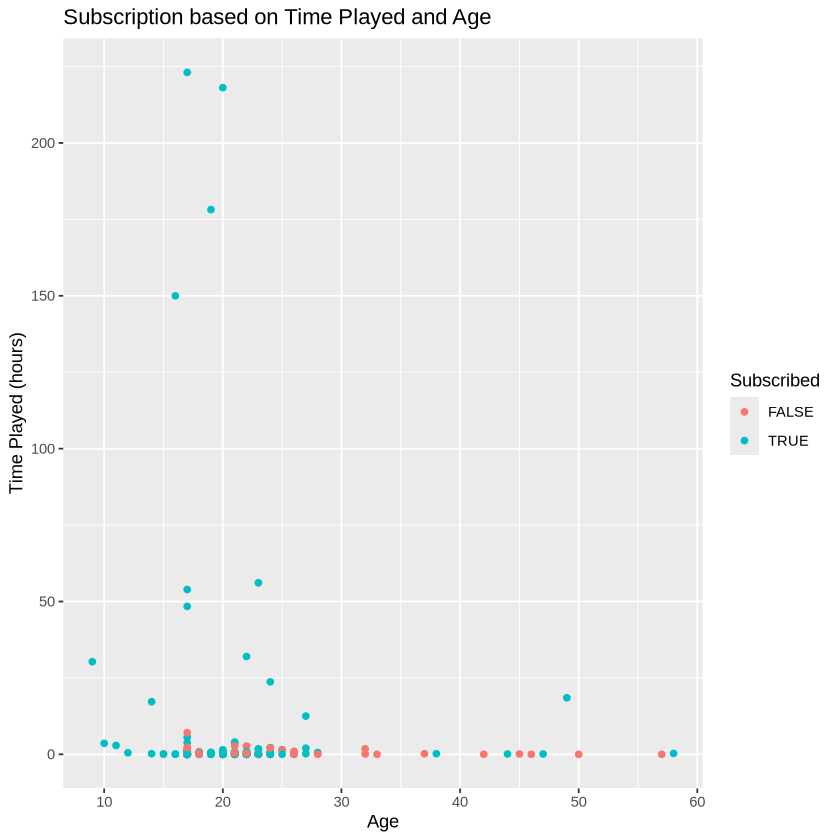

In [49]:
plot1 <- players |>
    ggplot(aes(x = Age, y = played_hours, color = subscribe)) +
    geom_point() +
    labs(x = "Age", y = "Time Played (hours)", color = "Subscribed", title = "Subscription based on Time Played and Age")
plot1

Notes: 
- it could be potentially difficult to predict subscription rates based on the age and time played (many people have not spent much time playing)


Warning message:
“Removed 2 rows containing non-finite outside the scale range (`stat_count()`).”


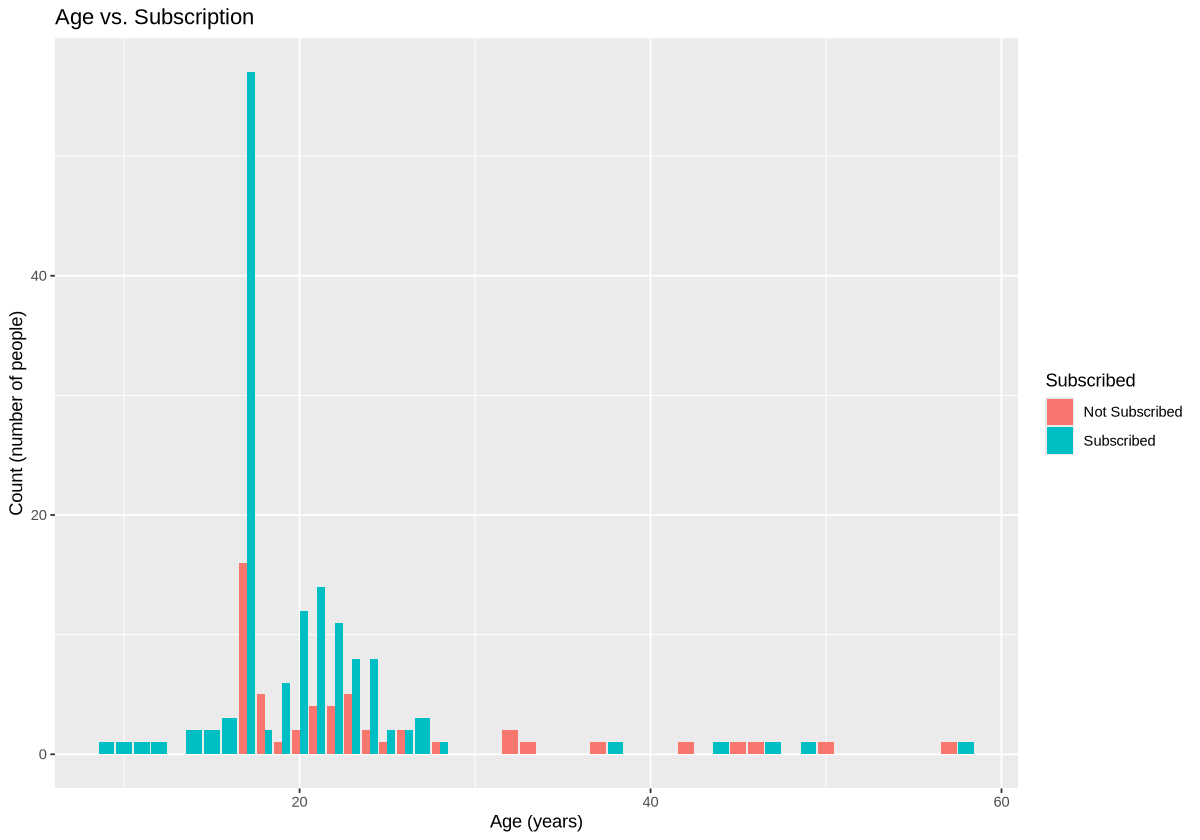

In [61]:
options(repr.plot.height = 7, repr.plot.width = 10)

plot2 <- players |>
    ggplot(aes(x = Age, fill = subscribe)) +
    geom_bar(position = "dodge") +
    labs(x = "Age (years)", y = "Count (number of people)", title = "Age and Subscription Status", fill = "Subscribed") +
    scale_fill_discrete(labels = c("FALSE" = "Not Subscribed", "TRUE" = "Subscribed"))
plot2

Notes:
- the plot differentiates between the people subscribed and not subscribed, but again there may not be enough people to determine whether there is a correlation between age and subscription status